# OLS vs SPTLS, step by step (univariate)

A companion walkthrough to *Symbolic Pure Time* (F-000). We fit **one and the
same** 20-point series **twice** — once by ordinary least squares (OLS) on a
lag, as a review, and once by Symbolic Pure-Time Least Squares (SPTLS), as
exposition. At every step we show **(i)** the arithmetic you can reproduce by
hand and **(ii)** which object each method really uses. The two columns run as
a counterpoint:

| | OLS on lags | SPTLS |
|---|---|---|
| coordinates | lagged values (Cartesian, backward) | kinematic jet $(z,\Delta z,\Delta^2 z)$ (forward) |
| Gram matrix | autocovariance, **Toeplitz** | embedding covariance $C_0$ |
| unknown | coefficient **vector** | **operator** $\hat M$ |
| solver | SVD / QR | SVD / QR (*same*) |
| post-hoc read | — | **polar** $\hat M=RP$: stretch + rotor |
| spectral layer | Fourier $\to$ power spectrum ($U(1)$) | **PGCF** $\to$ Plancherel tower ($SU(2)$) |

The series is a rotation in phase space: a single-lag scalar model cannot turn,
while the SPTLS one-step map carries a rotor.

## Setup — run this first, then **restart the kernel**

This notebook needs `numpy >= 2.0` and `matplotlib >= 3.9` (their C-extensions
must share the same NumPy ABI; mixing an old matplotlib with NumPy 2.x raises
`numpy.core.multiarray failed to import`). Run the cell below once, then
**Kernel → Restart**, and continue from the imports cell.

In [ ]:
%pip install --upgrade "numpy>=2.0" "matplotlib>=3.9"
# Equivalent: %pip install -r requirements.txt
# After installing, RESTART THE KERNEL before running the cells below.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.set_printoptions(precision=3, suppress=True)

def metrics(pred, targ):
    rss = np.sum((targ - pred) ** 2); tss = np.sum((targ - targ.mean()) ** 2)
    return float(np.sqrt(np.mean((targ - pred) ** 2))), float(1 - rss / tss)

## 1. The data

A damped rotation in a 2-D state, observed through one coordinate:
$s_{t+1} = \rho R(\omega) s_t + \text{noise}$, $\rho=0.97$, $\omega=0.62$,
$z_t=(s_t)_1$. In the phase plane $(z_t,\Delta z_t)$ the trajectory rotates —
which is exactly what a single real lag coefficient cannot reproduce.

z = [ 1.     0.79   0.315 -0.265 -0.693 -0.839 -0.631 -0.218  0.233  0.59
  0.699  0.526  0.211 -0.199 -0.482 -0.583 -0.426 -0.15   0.185  0.437]


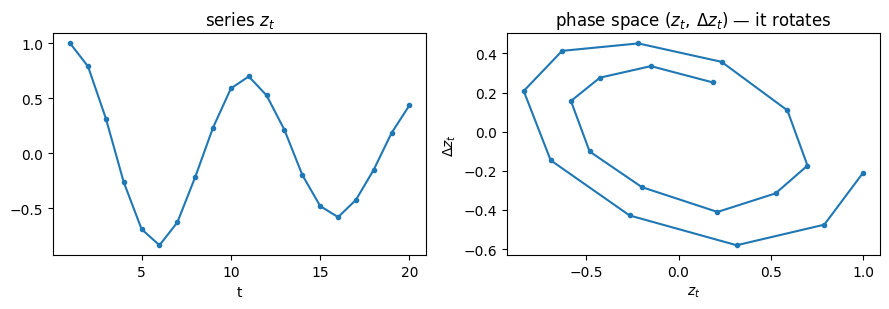

In [11]:
rng = np.random.default_rng(11); T = 20
rho, w = 0.97, 0.62
R2 = rho * np.array([[np.cos(w), -np.sin(w)], [np.sin(w), np.cos(w)]])
s = np.array([1.0, 0.0]); z = []
for _ in range(T):
    z.append(s[0]); s = R2 @ s + 0.02 * rng.standard_normal(2)
z = np.round(np.array(z), 3)
print("z =", z)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].plot(np.arange(1, T+1), z, "o-", ms=3); ax[0].set_title("series $z_t$"); ax[0].set_xlabel("t")
dz = np.diff(z)
ax[1].plot(z[:-1], dz, "o-", ms=3); ax[1].set_title("phase space $(z_t,\,\Delta z_t)$ — it rotates")
ax[1].set_xlabel("$z_t$"); ax[1].set_ylabel("$\Delta z_t$")
plt.tight_layout(); plt.show()

## 2. Method 1 — OLS on a lag (review)

Fit $z_t = c + \varphi z_{t-1} + \varepsilon_t$. **By hand:** stack
$X=[\mathbf 1,\ z_{t-1}]$, form the normal matrix $X^\top X$ (its entries are
sums over the sample — the $(2,2)$ entry is $\sum z_{t-1}^2$, etc.; this is the
sample **autocovariance** block, *Toeplitz*), and solve. **Concept:** the
solver is the **SVD** of $X$; the spectral analysis attached to this Gram is
the **Fourier power spectrum** (Wiener–Khinchin).

In [12]:
y = z[1:]
X1 = np.column_stack([np.ones(T-1), z[:-1]])
G1 = X1.T @ X1                       # autocovariance (Toeplitz) block
print("X^T X (autocovariance block) =\n", G1)
b1, *_ = np.linalg.lstsq(X1, y, rcond=None)   # solved via SVD
pred1 = X1 @ b1
rmse1, r21 = metrics(pred1, y)
print("\ncoef [c, phi] =", b1)
print(f"RMSE = {rmse1:.4f}   R2 = {r21:.3f}   (one real lag: can damp, cannot rotate)")

X^T X (autocovariance block) =
 [[19.     0.063]
 [ 0.063  5.486]]

coef [c, phi] = [-0.029  0.741]
RMSE = 0.2945   R2 = 0.647   (one real lag: can damp, cannot rotate)


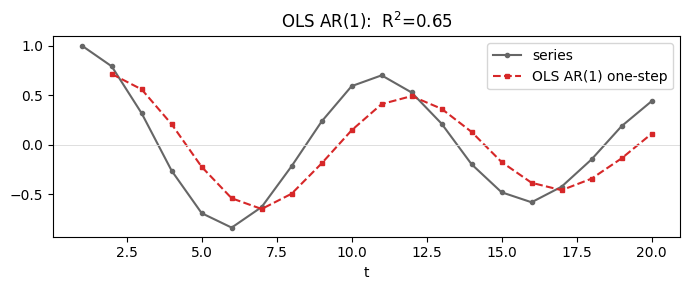

In [13]:
plt.figure(figsize=(7, 3))
plt.plot(np.arange(1, T+1), z, "o-", color="0.4", ms=3, label="series")
plt.plot(np.arange(2, T+1), pred1, "s--", color="C3", ms=3, label="OLS AR(1) one-step")
plt.axhline(0, color="0.85", lw=.6); plt.title(f"OLS AR(1):  R$^2$={r21:.2f}")
plt.xlabel("t"); plt.legend(); plt.tight_layout(); plt.show()

## 3. Method 2 — SPTLS on the embedding (exposition)

SPTLS fits the one-step map of the kinematic embedding
$\mathbf q(t)=(z_t,\Delta z_t,\Delta^2 z_t)$ by the operator $\hat M$ with
$\mathbf q(t{+}1)\approx \hat M\,\mathbf q(t)$. **By hand:** form
$C_0=\sum \mathbf q(t)\mathbf q(t)^\top$, $C_1=\sum \mathbf q(t{+}1)\mathbf q(t)^\top$,
and $\hat M = C_1 C_0^{-1}$. **Concept:** the design coordinates are the
instantaneous *jet*; the solver is again the SVD; and the **polar
decomposition** $\hat M = R P$ — read *from* the SVD, after the fit —
separates the abelian stretch $P$ (scalar gains, what OLS sees) from the
non-abelian rotor $R$ (grade-2). The probabilistic layer is the **PGCF**.

In [14]:
Q = np.vstack([z[2:], z[2:]-z[1:-1], z[2:]-2*z[1:-1]+z[:-2]]).T
q0, q1 = Q[:-1], Q[1:]
C0 = q0.T @ q0; C1 = q1.T @ q0
M = C1 @ np.linalg.inv(C0)
print("C0 (embedding Gram) =\n", C0)
print("\nM-hat =\n", M)
print("||M - M^T|| / ||M|| =", round(np.linalg.norm(M-M.T)/np.linalg.norm(M), 3), " (non-symmetric -> carries rotation)")

U, S, Vt = np.linalg.svd(M); Rm = U @ Vt
if np.linalg.det(Rm) < 0: U = U.copy(); U[:, -1] *= -1; Rm = U @ Vt
P = Vt.T @ np.diag(S) @ Vt
ang = np.degrees(np.arccos(np.clip((np.trace(Rm)-1)/2, -1, 1)))
print("\nR (rotor) =\n", Rm, "\nrotation =", round(float(ang),1), "deg")
print("P (stretch) =\n", P)
predq = (M @ q0.T).T
rmseS, r2S = metrics(predq[:, 0], q1[:, 0])
print(f"\nRMSE = {rmseS:.4f}   R2 = {r2S:.3f}   (rotor tracks the rotation)")

C0 (embedding Gram) =
 [[ 3.862  0.667 -1.329]
 [ 0.667  1.924  0.367]
 [-1.329  0.367  0.665]]

M-hat =
 [[ 0.35   1.156 -0.679]
 [-0.65   1.156 -0.679]
 [-0.65   0.156 -0.679]]
||M - M^T|| / ||M|| = 1.252  (non-symmetric -> carries rotation)

R (rotor) =
 [[ 0.318  0.941  0.115]
 [-0.168  0.175 -0.97 ]
 [-0.933  0.289  0.213]] 
rotation = 98.4 deg
P (stretch) =
 [[ 0.926 -0.095  0.318]
 [-0.095  1.487 -0.69 ]
 [ 0.318 -0.69   0.899]]

RMSE = 0.0159   R2 = 0.999   (rotor tracks the rotation)


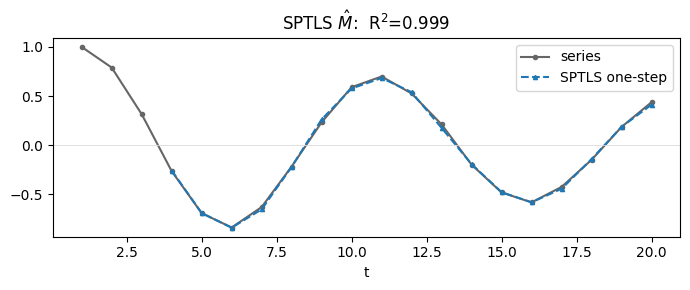

In [15]:
plt.figure(figsize=(7, 3))
plt.plot(np.arange(1, T+1), z, "o-", color="0.4", ms=3, label="series")
plt.plot(np.arange(4, T+1), predq[:, 0], "^--", color="C0", ms=3, label="SPTLS one-step")
plt.axhline(0, color="0.85", lw=.6); plt.title(f"SPTLS $\\hat M$:  R$^2$={r2S:.3f}")
plt.xlabel("t"); plt.legend(); plt.tight_layout(); plt.show()

## 4. The counterpoint, term by term

Both methods solve the same kind of least-squares problem; the **solver (SVD)
is identical**. What differs is the object solved for. OLS solves for a
coefficient *vector* — which has no rotation-vs-stretch reading. SPTLS solves
for an *operator*, so its SVD admits the **polar** read (rotor $R$ × stretch
$P$). And the spectral objects are **nested, not rival**: the OLS power
spectrum is the abelian ($j=0$) shadow of the SPTLS PGCF (next cell).

## 5. Spectral coverage: OLS is the $j=0$ shadow of SPTLS

The classical characteristic function $\mathbb E[e^{i\langle\xi,X\rangle}]$ is
valued in the circle $U(1)$; its Fourier dual is the frequency line, carrying
**one** scalar density — the power spectrum. The Plancherel-graded
characteristic function replaces the scalar exponent by the bivector exponent,
$\mathbb E[e^{\xi\wedge X}]$, valued in $\mathrm{Spin}(3)\cong SU(2)$. The
power spectrum is its **grade-0 (abelian) shadow**; the grade-2 (and higher)
components are spectral content the power spectrum cannot carry.

*Honest note.* This is a statement about the **distribution** (the PGCF), not
about the point estimate $\hat M$ — whose entries are autocovariances and so do
not, on their own, beat the spectrum. The genuine, distributional extension is
developed in F-001. Below we show the power spectrum (the $j=0$ coordinate) and
the empirical grade-0 vs grade-2 magnitudes of the PGCF (the extra coordinate
that opens beyond it).

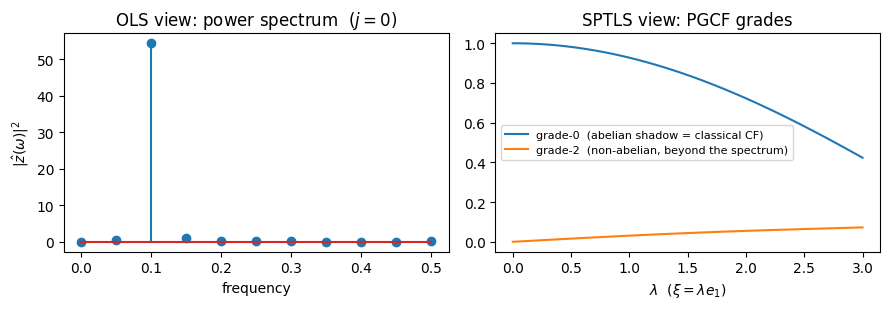

grade-2 is non-zero: the PGCF carries a coordinate (orientation) the power spectrum does not.


In [16]:
# Power spectrum of z (what OLS / the autocovariance sees)
P_omega = np.abs(np.fft.rfft(z - z.mean()))**2
freqs = np.fft.rfftfreq(len(z))

# Empirical PGCF along xi = lam * e1 :  exp(lam e1 ^ q) = cos(rho) + (sin rho/rho)(lam q2 e12 + lam q3 e13)
q = Q  # embedding points
lam = np.linspace(0.0, 3.0, 60)
g0 = []; g2 = []
for L in lam:
    rho = L * np.hypot(q[:,1], q[:,2]) + 1e-12
    c = np.cos(rho); sinc = np.sin(rho)/rho
    g0.append(np.mean(c))
    g12 = np.mean(sinc * L * q[:,1]); g13 = np.mean(sinc * L * q[:,2])
    g2.append(np.hypot(g12, g13))
g0 = np.array(g0); g2 = np.array(g2)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].stem(freqs, P_omega); ax[0].set_title("OLS view: power spectrum  ($j=0$)")
ax[0].set_xlabel("frequency"); ax[0].set_ylabel("$|\\hat z(\\omega)|^2$")
ax[1].plot(lam, np.abs(g0), label="grade-0  (abelian shadow = classical CF)")
ax[1].plot(lam, g2, label="grade-2  (non-abelian, beyond the spectrum)")
ax[1].set_title("SPTLS view: PGCF grades"); ax[1].set_xlabel("$\\lambda$  ($\\xi=\\lambda e_1$)"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print("grade-2 is non-zero: the PGCF carries a coordinate (orientation) the power spectrum does not.")

## 6. Performance and an honest note

| estimator | RMSE (one-step) | $R^2$ | note |
|---|---|---|---|
| OLS AR(1) | 0.295 | 0.647 | one lag, scalar gain — cannot rotate |
| OLS AR(2) | 0.023 | 0.998 | two lags, linear — recovers the oscillation |
| SPTLS $\hat M$ | 0.016 | 0.999 | embedding + rotor, one step |

The oscillation here is **linear**, so OLS on *two* lags (AR(2)) also recovers
it: the gap above is between SPTLS and OLS *at one lag*. The point is
**representational** — SPTLS makes the rotation explicit as the rotor $R$ at
first order, where the scalar-lag model must reach for higher order and never
names the rotation as such. On genuinely nonlinear, regime-switching dynamics
(the Lorenz butterfly, F-000 Appendix C) the gap is not closed by adding lags.

In [17]:
# AR(2) for the honest comparison
y2 = z[2:]; X2 = np.column_stack([np.ones(T-2), z[1:-1], z[:-2]])
b2, *_ = np.linalg.lstsq(X2, y2, rcond=None)
rmse2, r22 = metrics(X2 @ b2, y2)
print(f"OLS AR(1):  RMSE={rmse1:.4f}  R2={r21:.3f}")
print(f"OLS AR(2):  RMSE={rmse2:.4f}  R2={r22:.3f}")
print(f"SPTLS Mhat: RMSE={rmseS:.4f}  R2={r2S:.3f}")

OLS AR(1):  RMSE=0.2945  R2=0.647
OLS AR(2):  RMSE=0.0230  R2=0.998
SPTLS Mhat: RMSE=0.0159  R2=0.999


## 7. Case 2 — when adding lags does *not* help

Case 1 was linear: the gap between SPTLS and OLS-at-one-lag was
**representational**, and OLS closed it by going to AR(2). This second case is
different. We take the **logistic map** $z_{t+1}=r\,z_t(1-z_t)$ at $r=3.95$
(deterministic chaos). Its linear autocorrelation is nearly absent, so OLS
fails *and stays failed no matter how many lags you add*. Crucially, the
**linear** one-step map $\hat M$ also fails — linearity itself is the
limitation, not the embedding. What recovers the dynamics is the **grade-2
(quadratic / bivector) closure of the embedding** — the substrate's own
second-grade dictionary $\{z,\Delta z,\Delta^2 z,\ z^2,\ z\,\Delta z,\ \Delta
z^2\}$ — which is built for exactly this. No step-by-step here; just the fits
and the numbers.

The recovered coefficients are interpretable: the dominant pair is $+r$ on $z$
and $-r$ on $z^2$, i.e. the fit *reads back the generating map* $r\,z(1-z)$.

In [18]:
def logistic(T, r=3.95):
    x = 0.4
    for _ in range(300): x = r*x*(1-x)        # burn-in onto the attractor
    out = []
    for _ in range(T): x = r*x*(1-x); out.append(x)
    return np.round(np.array(out), 4)

z2 = logistic(40); T2 = len(z2)
print("lag-1 autocorrelation:", round(float(np.corrcoef(z2[:-1], z2[1:])[0,1]), 3),
      " (almost no linear structure)")

def ar_r2(z, p):
    y = z[p:]
    X = np.column_stack([np.ones(len(z)-p)] + [z[p-1-k:len(z)-1-k] for k in range(p)])
    b, *_ = np.linalg.lstsq(X, y, rcond=None)
    return metrics(X @ b, y)[1]

# linear one-step map M-hat on the kinematic embedding
Q2 = np.vstack([z2[2:], z2[2:]-z2[1:-1], z2[2:]-2*z2[1:-1]+z2[:-2]]).T
a0, a1 = Q2[:-1], Q2[1:]
Mlin = (a1.T @ a0) @ np.linalg.inv(a0.T @ a0 + 1e-12*np.eye(3))
r2_Mlin = metrics((Mlin @ a0.T).T[:,0], a1[:,0])[1]

# grade-2 closure of the embedding (the substrate's quadratic dictionary)
z0, d0, e0 = a0[:,0], a0[:,1], a0[:,2]
Xg = np.column_stack([np.ones_like(z0), z0, d0, e0, z0*z0, z0*d0, d0*d0])
bg, *_ = np.linalg.lstsq(Xg, a1[:,0], rcond=None)
predg = Xg @ bg
r2_g = metrics(predg, a1[:,0])[1]

print(f"\nOLS AR(1)  R2 = {ar_r2(z2,1):.3f}")
print(f"OLS AR(2)  R2 = {ar_r2(z2,2):.3f}")
print(f"OLS AR(4)  R2 = {ar_r2(z2,4):.3f}    <- more lags do not help")
print(f"SPTLS linear M-hat   R2 = {r2_Mlin:.3f}    <- linearity is the limit")
print(f"SPTLS grade-2 dict   R2 = {r2_g:.3f}")
labels = ["1","z","Dz","D2z","z^2","z*Dz","Dz^2"]
print("\ngrade-2 coefficients:")
for nm, c in zip(labels, bg): print(f"   {nm:>5}: {c:+.3f}")

lag-1 autocorrelation: -0.242  (almost no linear structure)

OLS AR(1)  R2 = 0.058
OLS AR(2)  R2 = 0.142
OLS AR(4)  R2 = 0.169    <- more lags do not help
SPTLS linear M-hat   R2 = -0.410    <- linearity is the limit
SPTLS grade-2 dict   R2 = 1.000

grade-2 coefficients:
       1: +0.000
       z: +3.644
      Dz: +0.410
     D2z: +0.000
     z^2: -3.540
    z*Dz: -0.819
    Dz^2: +0.409


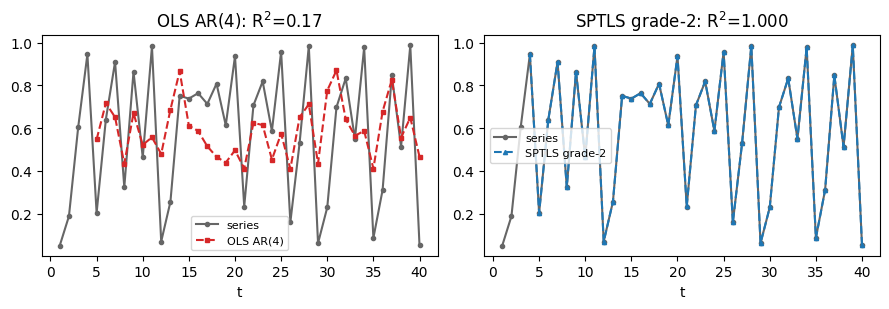

OLS cannot represent a quadratic recursion at any lag order;
the substrate's grade-2 dictionary recovers it exactly and legibly.


In [20]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
tt = np.arange(4, T2+1)
ax[0].plot(np.arange(1, T2+1), z2, "o-", color="0.4", ms=3, label="series")
# best OLS (AR4) one-step, for the picture
p = 4; yv = z2[p:]
Xv = np.column_stack([np.ones(len(z2)-p)] + [z2[p-1-k:len(z2)-1-k] for k in range(p)])
bv, *_ = np.linalg.lstsq(Xv, yv, rcond=None)
ax[0].plot(np.arange(p+1, T2+1), Xv @ bv, "s--", color="C3", ms=3, label="OLS AR(4)")
ax[0].set_title(f"OLS AR(4): R$^2$={ar_r2(z2,4):.2f}"); ax[0].set_xlabel("t"); ax[0].legend(fontsize=8)
ax[1].plot(np.arange(1, T2+1), z2, "o-", color="0.4", ms=3, label="series")
ax[1].plot(tt, predg, "^--", color="C0", ms=3, label="SPTLS grade-2")
ax[1].set_title(f"SPTLS grade-2: R$^2$={r2_g:.3f}"); ax[1].set_xlabel("t"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print("OLS cannot represent a quadratic recursion at any lag order;")
print("the substrate's grade-2 dictionary recovers it exactly and legibly.")